In [14]:
%reload_ext autoreload
%autoreload 2

In [15]:
from waymo_agent import *

In [ ]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *

In [17]:
G_raw = ox.graph_from_place(
    "Manhattan, New York, USA",
    network_type="drive",
    simplify=True,
)


print(f"Nodes: {G_raw.number_of_nodes()}")
print(f"Edges: {G_raw.number_of_edges()}")

Nodes: 4619
Edges: 9901


## Basic Save / Load

In [18]:
MAP_DIR

PosixPath('/Users/Akseldkw/coding/Columbia/RL-Project/maps')

In [19]:
ox.save_graphml(G_raw, filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

In [20]:
G_out = load_graph_type_preserved(filepath=MAP_DIR / MANHATTAN_RAW_GRAPH)

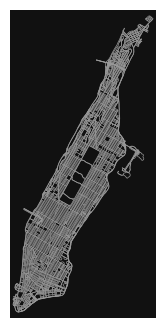

In [21]:
fig, ax = ox.plot_graph(G_out, node_size=0, edge_linewidth=0.5, figsize=(4, 4))

## Preprocess Graph

In [22]:
G = clean_graph(G_raw)

In [23]:
collect_unique_graph_attr(G, "maxspeed")

{2, 5, 10, 14, 15, 18, 20, 22, 25, 28, 30, 32, 35, 40, 44, 45, 48, 50}

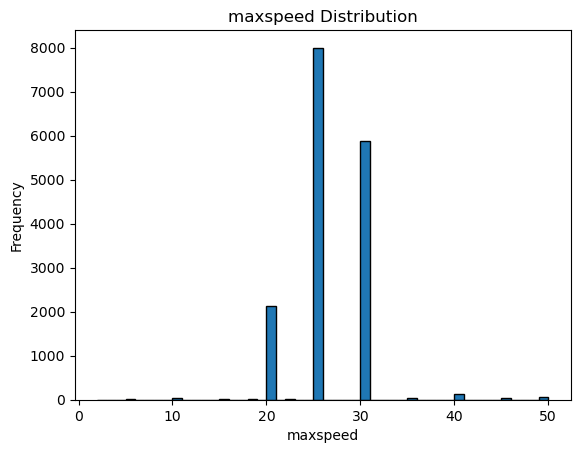

In [24]:
plot_maxspeed(G)

In [25]:
collect_unique_graph_attr(G, "maxspeed")

{2, 5, 10, 14, 15, 18, 20, 22, 25, 28, 30, 32, 35, 40, 44, 45, 48, 50}

In [26]:
ox.save_graphml(G, filepath=MAP_DIR / MANHATTAN_CLEANED_GRAPH)

## Sparsify Graph

In [27]:
G = sparsify_graph(G)

Removing 7861 non-major edges...
Graph after edge removal: G_sparsified.number_of_nodes()=3517, G_sparsified.number_of_edges()=8502
Cleaning all edge attributes before simplification...
Cleaning all edge attributes before simplification...
Removing 62 isolated or pass-through nodes...
Cleaning all edge attributes before simplification...
Final simplified graph: G_ret.number_of_nodes()=782, G_ret.number_of_edges()=2746


In [29]:
sparse_graph_name = MANHATTAN_SPARSE_GRAPH.format(G.number_of_nodes())
sparse_graph_name

'manhattan-sparse-782-nodes.graphml'

In [30]:
ox.save_graphml(G, filepath=MAP_DIR / sparse_graph_name)

#### Load Sparse Graph

In [31]:
G = load_graph_type_preserved(filepath=MAP_DIR / sparse_graph_name)

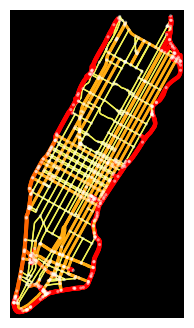

In [32]:
edge_colors, edge_widths = OSMNXConstants.get_edge_colors(G)
fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    **{**DEFAULT_OX_PLOT_NOTEBOOK | {"figsize": (4, 4)}},
)

## Enrich Graph 

Add lambda (demand) and charger info

In [33]:
G = load_graph_type_preserved(filepath=MAP_DIR / sparse_graph_name)
post_load(G)

In [34]:
enrich_graph(G)

Assigned lambda values to nodes. Total lambda: 4.4920 (target: 3.9100)


In [35]:
inspect_graph(G)

Graph has 782 nodes and 2746 edges.
Sample node -sample_node_id=12410398108- attributes: {'y': 40.7223439, 'x': -74.0118571, 'street_count': 3, 'lambda': 0.0, 'x_centered': -2678.5954, 'y_centered': -3654.5471, 'x_norm': -0.3752, 'y_norm': -0.5119}

Sample edge attributes: {'osmid': [958130664, 987645701], 'highway': 'motorway', 'lanes': [3], 'maxspeed': 40.0, 'name': 'FDR Drive', 'oneway': False, 'ref': 'FDR', 'reversed': False, 'length': 837.1069046211431, 'tunnel': ['building_passage', 'yes'], 'bridge': 'yes', 'geometry': <LINESTRING (-73.956 40.761, -73.958 40.759, -73.962 40.755)>, 'travel_time_minutes': 1.2557}

cls.edge_length_unit='meters', cls.speed_unit='km/h', cls.time_unit='minutes'


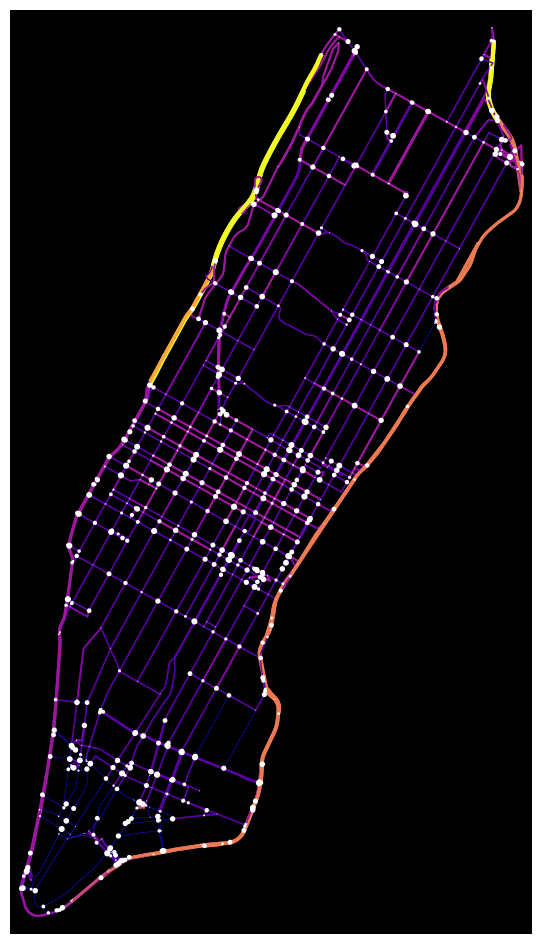

In [36]:
edge_colors, edge_widths = get_edge_color_by_speed(G)
node_colors, node_sizes = get_node_colors_and_sizes(G)
fig, ax = ox.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    node_size=node_sizes,
    node_color=node_colors,
    figsize=(12, 12),
    show=False,
    bgcolor="black",
)

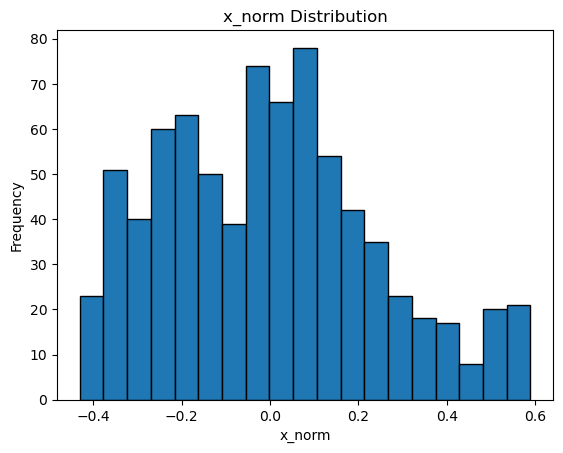

In [37]:
hist_edge_or_node_attr(G, "x_norm", "node")

Inspecting EDGE attributes in the graph.


/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7132: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


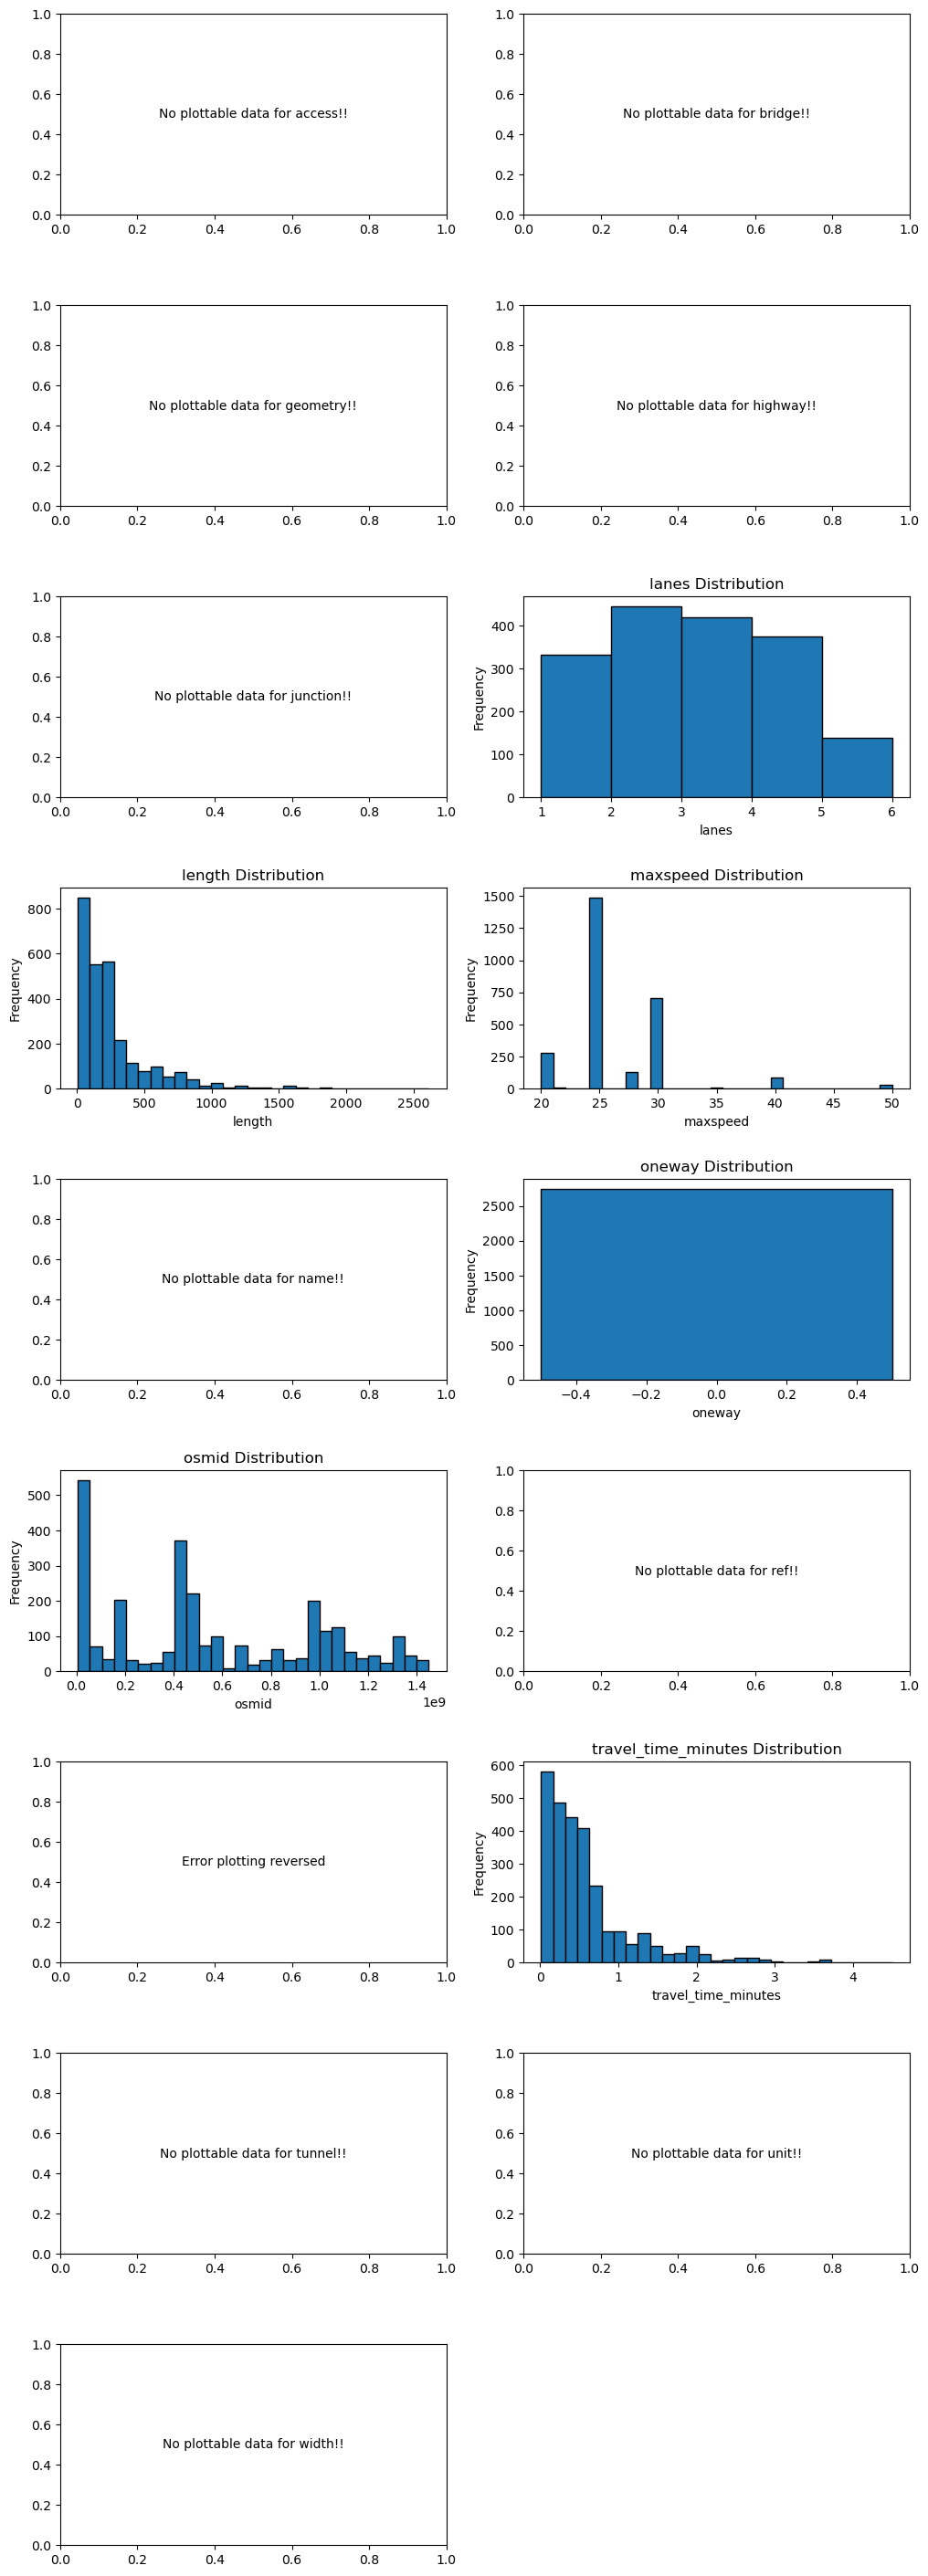

In [ ]:
hist_ALL(G, "edge")

Inspecting NODE attributes in the graph.


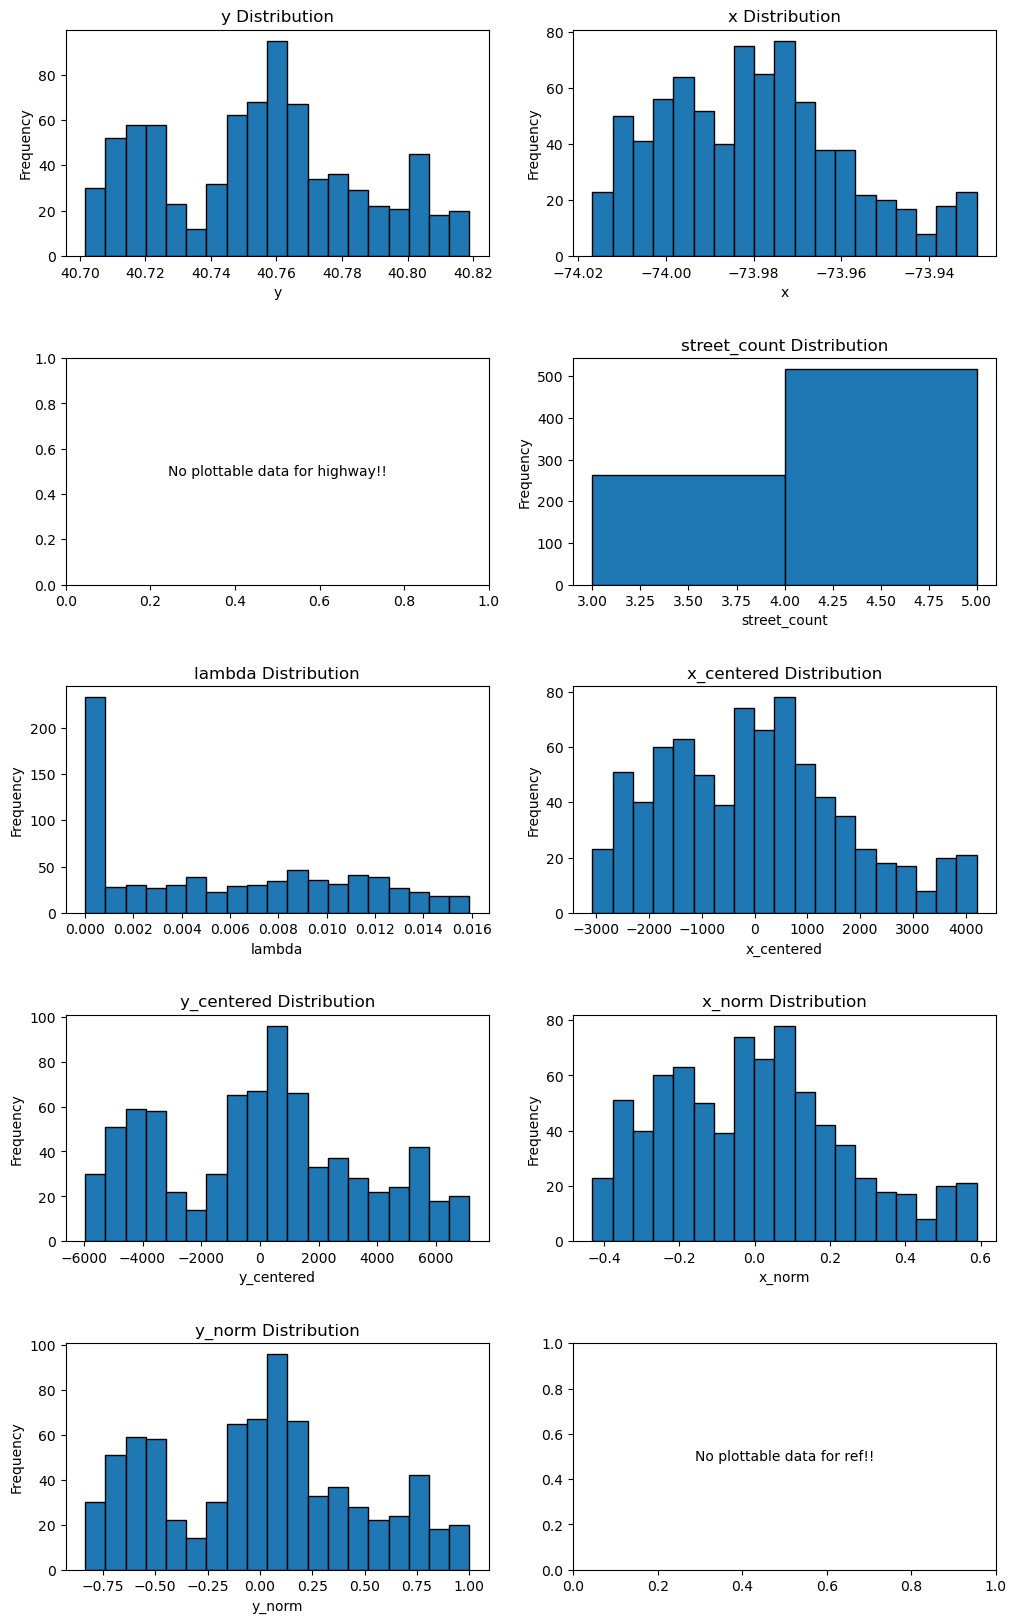

In [ ]:
hist_ALL(G, "node")

In [40]:
ox.save_graphml(G, filepath=MAP_DIR / MANHATTAN_ENRICHED_GRAPH.format(G.number_of_nodes()))